## 1. Problem Definition

BigMart wants to understand and predict how much revenue (`Item_Outlet_Sales`)
each product will generate at each of its outlets, using properties of the
item itself (weight, type, visibility, price) and properties of the outlet
(size, location tier, store format, age). This is a **regression**
problem — the target is continuous — evaluated primarily on **RMSE**
(root mean squared error, in the same rupee units as sales, penalizing
large misses more heavily), with MAE and R² reported alongside for a
fuller picture.

A good model here has real business value: it can guide inventory
allocation, identify underperforming product/outlet combinations, and
support new-outlet sales forecasting.

## 2. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import scipy.stats as stats

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42


## 3. Data Understanding

Each row is one product sold at one outlet. Features describe the item
(weight, fat content, visibility on the shelf, category, price) and the
outlet (identifier, founding year, size, location tier, store format).
The target, `Item_Outlet_Sales`, is the total sales of that item at that
outlet.

In [2]:
df = pd.read_csv('Train.csv')
print(f"Shape: {df.shape}")
df.head()


Shape: (8523, 12)


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Item_Weight,7060.0,12.857645,4.643456,4.555,8.773750,12.600000,16.850000,21.350000
Item_Visibility,8523.0,0.066132,0.051598,0.000,0.026989,0.053931,0.094585,0.328391
Item_MRP,8523.0,140.992782,62.275067,31.290,93.826500,143.012800,185.643700,266.888400
Outlet_Establishment_Year,8523.0,1997.831867,8.371760,1985.000,1987.000000,1999.000000,2004.000000,2009.000000
Item_Outlet_Sales,8523.0,2181.288914,1706.499616,33.290,834.247400,1794.331000,3101.296400,13086.964800


## 4. Data Quality Checks

Three issues were identified: missing values in Item_Weight and Outlet_Size, inconsistent labels in Item_Fat_Content, and zero values in Item_Visibility. The zero values are evaluated later using training-set cross-validation to avoid leakage. No duplicate rows were found.

In [5]:
print("Missing values:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")


Missing values:
Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

Duplicate rows: 0


**Inconsistent `Item_Fat_Content` labels:**

In [6]:
print(df['Item_Fat_Content'].value_counts())


Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64


In [7]:
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'low fat': 'Low Fat', 'LF': 'Low Fat', 'reg': 'Regular'
})
print("After standardizing:")
print(df['Item_Fat_Content'].value_counts())


After standardizing:
Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64


**Suspicious zero `Item_Visibility` values — flagged, decision deferred to Section 7:**

In [8]:
n_zero_vis = (df['Item_Visibility'] == 0).sum()
print(f"Rows with Item_Visibility == 0: {n_zero_vis} ({n_zero_vis/len(df)*100:.2f}%)")
print("Left as-is for now -- resolved empirically in Section 7, after the train/test split.")


Rows with Item_Visibility == 0: 526 (6.17%)
Left as-is for now -- resolved empirically in Section 7, after the train/test split.


## 5. Feature Engineering

Three features are engineered: Item_Category from Item_Identifier, Outlet_Age from the establishment year using 2013 as the reference year, and Visibility based on the zero-value treatment from Section 4. Item_Identifier and Outlet_Establishment_Year are then dropped.

In [9]:
df['Item_Category'] = df['Item_Identifier'].str[:2].map({
    'FD': 'Food', 'DR': 'Drinks', 'NC': 'Non-Consumable'
})
print(df['Item_Category'].value_counts())


Item_Category
Food              6125
Non-Consumable    1599
Drinks             799
Name: count, dtype: int64


In [10]:
REFERENCE_YEAR = 2013
df['Outlet_Age'] = REFERENCE_YEAR - df['Outlet_Establishment_Year']
df[['Outlet_Establishment_Year', 'Outlet_Age']].drop_duplicates().sort_values('Outlet_Age')


,Outlet_Establishment_Year,Outlet_Age
1,2009,4
9,2007,6
19,2004,9
8,2002,11
0,1999,14
3,1998,15
11,1997,16
4,1987,26
7,1985,28


In [11]:
df = df.drop(columns=['Item_Identifier', 'Outlet_Establishment_Year'])
df.head()


,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Category,Outlet_Age
0,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,Medium,Tier 1,Supermarket Type1,3735.1380,Food,14
1,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,Medium,Tier 3,Supermarket Type2,443.4228,Drinks,4
2,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,Medium,Tier 1,Supermarket Type1,2097.2700,Food,14
3,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,NaN,Tier 3,Grocery Store,732.3800,Food,15
4,8.93,Low Fat,0.000000,Household,53.8614,OUT013,High,Tier 3,Supermarket Type1,994.7052,Non-Consumable,26


## 6. Exploratory Data Analysis

**Target distribution.** `Item_Outlet_Sales` is right-skewed, as sales figures typically are — most item/outlet pairs generate modest sales, with a long tail of high performers.

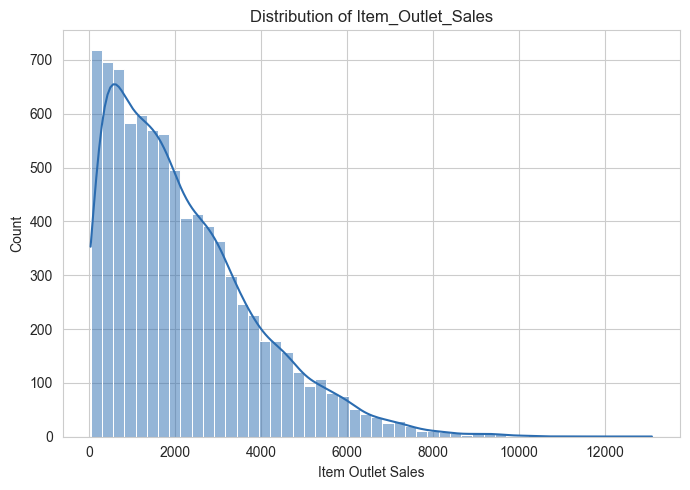

In [12]:
plt.figure(figsize=(7, 5))
sns.histplot(df['Item_Outlet_Sales'], bins=50, kde=True, color="#2b6cb0")
plt.title('Distribution of Item_Outlet_Sales')
plt.xlabel('Item Outlet Sales')
plt.tight_layout()
plt.show()


**Numeric feature distributions.**

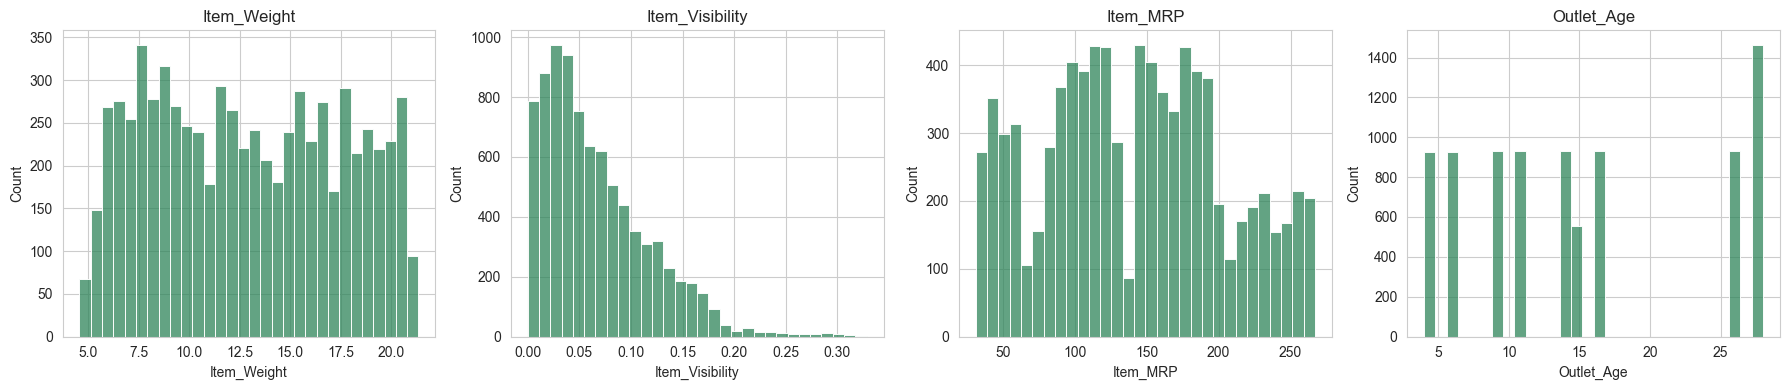

In [13]:
num_cols = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col].dropna(), bins=30, ax=ax, color="#2f855a")
    ax.set_title(col)
plt.tight_layout()
plt.show()


**Sales by categorical features.** Outlet type shows the clearest difference, with Grocery Stores having much lower sales than Supermarket formats. Outlet size and location tier show smaller differences.

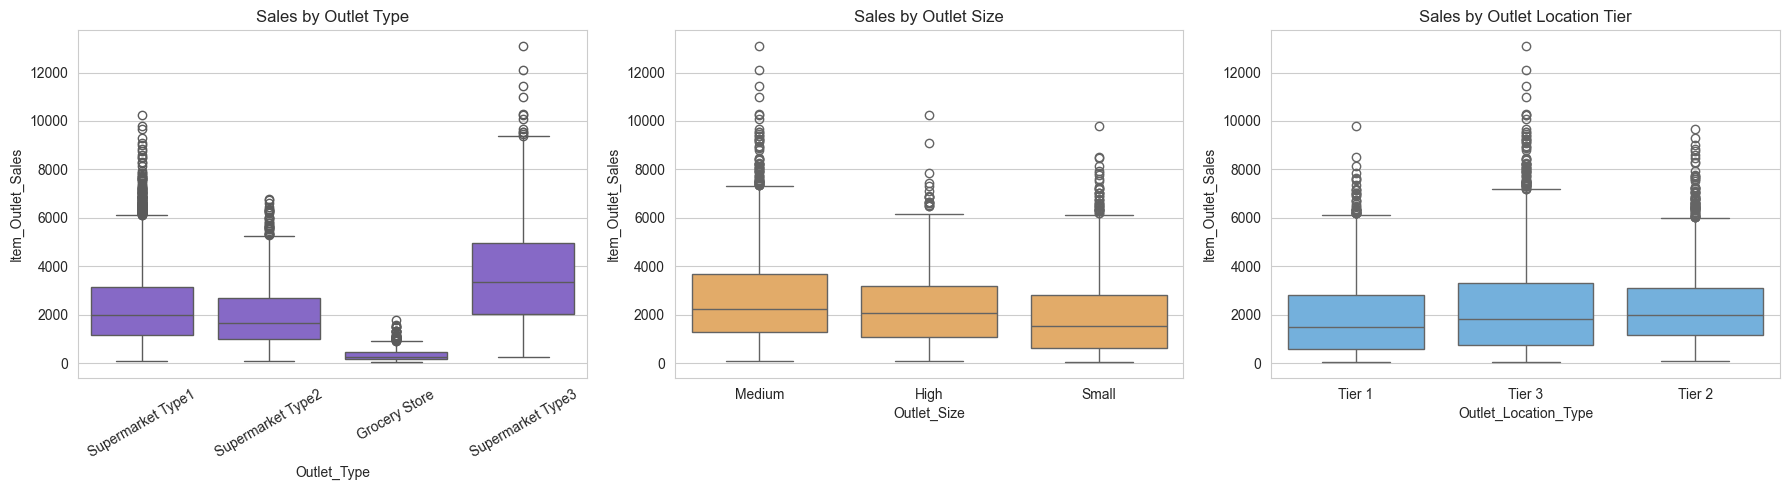

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(x='Outlet_Type', y='Item_Outlet_Sales', data=df, ax=axes[0], color="#805ad5")
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_title('Sales by Outlet Type')

sns.boxplot(x='Outlet_Size', y='Item_Outlet_Sales', data=df, ax=axes[1], color="#f6ad55")
axes[1].set_title('Sales by Outlet Size')

sns.boxplot(x='Outlet_Location_Type', y='Item_Outlet_Sales', data=df, ax=axes[2], color="#63b3ed")
axes[2].set_title('Sales by Outlet Location Tier')
plt.tight_layout()
plt.show()


**Item_MRP vs. sales.** Price is the strongest numeric predictor of sales, showing a clear non-linear, banded relationship. This suggests tree-based models may perform better than simple linear regression.

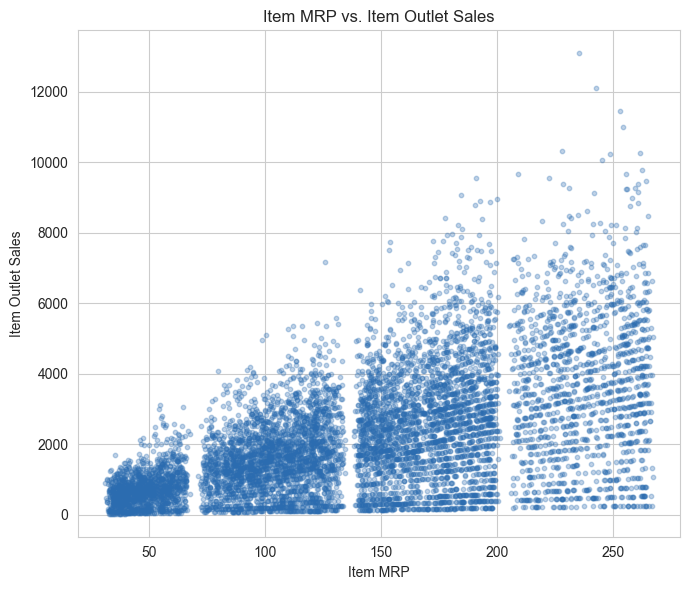

In [15]:
plt.figure(figsize=(7, 6))
plt.scatter(df['Item_MRP'], df['Item_Outlet_Sales'], alpha=0.3, s=10, color="#2b6cb0")
plt.xlabel('Item MRP'); plt.ylabel('Item Outlet Sales')
plt.title('Item MRP vs. Item Outlet Sales')
plt.tight_layout()
plt.show()


**Correlation among numeric features.**

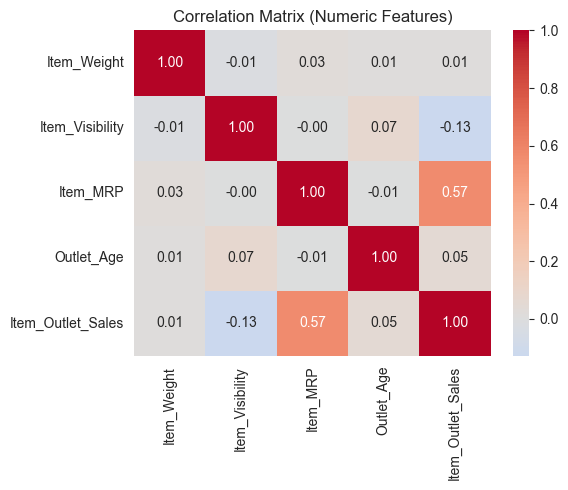

In [16]:
corr = df[num_cols + ['Item_Outlet_Sales']].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title('Correlation Matrix (Numeric Features)')
plt.tight_layout()
plt.show()


## 7. Train/Test Split

An 80/20 train-test split is performed before fitting any preprocessing steps, ensuring that imputation, encoding, and other decisions are based only on the training data to prevent data leakage.

In [17]:
target = 'Item_Outlet_Sales'
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")


Train: (6818, 11) | Test: (1705, 11)


**Resolving Item_Visibility Treatment**

The Item_Visibility treatment is selected using 5-fold cross-validation on the training set only. Two options are compared using RMSE with a Random Forest model, ensuring the test set does not influence the decision.

In [18]:
from sklearn.pipeline import Pipeline as _Pipeline
from sklearn.impute import SimpleImputer as _SimpleImputer
from sklearn.ensemble import RandomForestRegressor as _RandomForestRegressor

diag_features = ['Item_Weight', 'Item_Visibility', 'Item_MRP']
diag_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Option A: keep zeros as literal values, just median-impute the (unrelated) Item_Weight NaNs
X_keep_zeros = X_train[diag_features].copy()

# Option B: treat zeros as missing, then median-impute like any other missing value
X_zeros_as_missing = X_train[diag_features].copy()
X_zeros_as_missing['Item_Visibility'] = X_zeros_as_missing['Item_Visibility'].replace(0, np.nan)

diag_pipe = _Pipeline(steps=[
    ('imputer', _SimpleImputer(strategy='median')),
    ('model', _RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
])

rmse_keep = -cross_val_score(diag_pipe, X_keep_zeros, y_train,
                              cv=diag_cv, scoring='neg_root_mean_squared_error')
rmse_missing = -cross_val_score(diag_pipe, X_zeros_as_missing, y_train,
                                 cv=diag_cv, scoring='neg_root_mean_squared_error')

print(f"Option A -- keep zeros as-is:        CV RMSE = {rmse_keep.mean():,.1f} (+/- {rmse_keep.std():,.1f})")
print(f"Option B -- zeros treated as missing: CV RMSE = {rmse_missing.mean():,.1f} (+/- {rmse_missing.std():,.1f})")

treat_zeros_as_missing = rmse_missing.mean() <= rmse_keep.mean()
print(f"\nDecision (training set only): "
      f"{'treat zeros as missing' if treat_zeros_as_missing else 'keep zeros as-is'} (lower CV RMSE wins)")


Option A -- keep zeros as-is:        CV RMSE = 1,479.9 (+/- 14.9)
Option B -- zeros treated as missing: CV RMSE = 1,475.1 (+/- 22.3)

Decision (training set only): treat zeros as missing (lower CV RMSE wins)


In [19]:
if treat_zeros_as_missing:
    X_train = X_train.copy()
    X_test = X_test.copy()
    X_train['Item_Visibility'] = X_train['Item_Visibility'].replace(0, np.nan)
    X_test['Item_Visibility'] = X_test['Item_Visibility'].replace(0, np.nan)
    print("Applied to both X_train and X_test: Item_Visibility zeros converted to missing "
          "(will be imputed in the preprocessing pipeline, Section 8). Note this is a fixed, "
          "deterministic rule with no fitted parameters -- applying it to X_test does not leak "
          "anything, since only the *decision* of which rule to use was made from training data.")
else:
    print("Item_Visibility zeros left as-is in both X_train and X_test, per the training-set diagnostic above.")


Applied to both X_train and X_test: Item_Visibility zeros converted to missing (will be imputed in the preprocessing pipeline, Section 8). Note this is a fixed, deterministic rule with no fitted parameters -- applying it to X_test does not leak anything, since only the *decision* of which rule to use was made from training data.


## 8. Preprocessing Pipeline

Grouped-mode imputation: Missing Outlet_Size values are filled using the most common size within each Outlet_Type.
ColumnTransformer: Numeric features are median-imputed and standardized, while categorical features are imputed and one-hot encoded.
Both steps are included in the model pipeline, ensuring preprocessing is fitted separately within each cross-validation fold and preventing data leakage.

In [20]:
class GroupModeImputer(BaseEstimator, TransformerMixin):
    """Fill missing values in `target_col` with the most frequent value
    of `target_col` within each `group_col` group, learned at fit time
    from training data only (leakage-safe across CV folds)."""
    def __init__(self, group_col, target_col):
        self.group_col = group_col
        self.target_col = target_col

    def fit(self, X, y=None):
        modes = X.groupby(self.group_col)[self.target_col] \
                 .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
        self.group_modes_ = modes
        self.global_mode_ = X[self.target_col].mode().iloc[0]
        return self

    def transform(self, X):
        X = X.copy()
        missing = X[self.target_col].isnull()
        fill_values = X.loc[missing, self.group_col].map(self.group_modes_).fillna(self.global_mode_)
        X.loc[missing, self.target_col] = fill_values
        return X


In [21]:
numeric_features = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age']
categorical_features = ['Item_Fat_Content', 'Item_Type', 'Item_Category',
                         'Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

column_transformer = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

preprocessor = Pipeline(steps=[
    ('outlet_size_imputer', GroupModeImputer(group_col='Outlet_Type', target_col='Outlet_Size')),
    ('column_transformer', column_transformer),
])
print("Preprocessing pipeline defined.")


Preprocessing pipeline defined.


## 9. Linear Regression Baseline

A simple Linear Regression model is used as an interpretable baseline with the same leakage-safe preprocessing pipeline. This provides a reference for evaluating more complex ensemble models and enables linearity assumption checks.

In [22]:
lr_baseline_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', LinearRegression())])
lr_baseline_pipe.fit(X_train, y_train)

y_train_pred_lr = lr_baseline_pipe.predict(X_train)
lr_train_residuals = y_train.values - y_train_pred_lr
print("Linear Regression baseline fit on the training set.")


Linear Regression baseline fit on the training set.


## 10. Linear Regression Assumption Checks

The linear regression assumptions are checked using training-set residuals only before moving to more complex models. This ensures the diagnostics evaluate the fitted model without using the test set.

### 10.1 Linearity

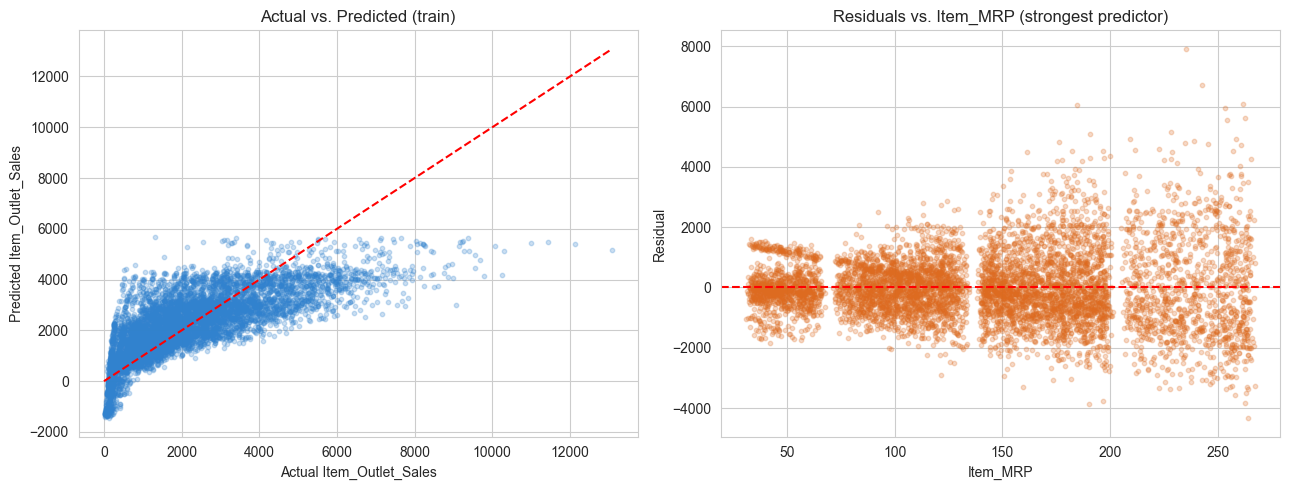

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_train, y_train_pred_lr, alpha=0.25, s=10, color="#3182ce")
lims = [0, max(y_train.max(), y_train_pred_lr.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5)
axes[0].set_xlabel('Actual Item_Outlet_Sales'); axes[0].set_ylabel('Predicted Item_Outlet_Sales')
axes[0].set_title('Actual vs. Predicted (train)')

axes[1].scatter(X_train['Item_MRP'], lr_train_residuals, alpha=0.25, s=10, color="#dd6b20")
axes[1].axhline(0, color='r', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Item_MRP'); axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs. Item_MRP (strongest predictor)')

plt.tight_layout()
plt.show()


### 10.2 Independence of Errors

Durbin-Watson statistic: 1.952  (~2.0 indicates no autocorrelation)


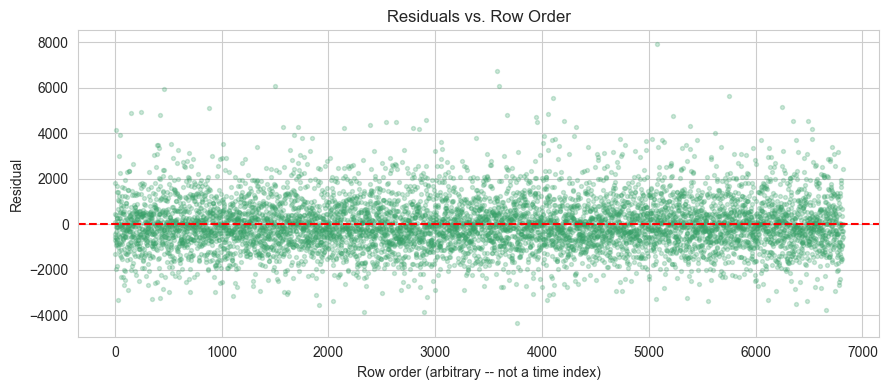

In [24]:
dw_stat = durbin_watson(lr_train_residuals)
print(f"Durbin-Watson statistic: {dw_stat:.3f}  (~2.0 indicates no autocorrelation)")

plt.figure(figsize=(9, 4))
plt.scatter(range(len(lr_train_residuals)), lr_train_residuals, alpha=0.25, s=8, color="#38a169")
plt.axhline(0, color='r', linestyle='--', linewidth=1.5)
plt.xlabel('Row order (arbitrary -- not a time index)'); plt.ylabel('Residual')
plt.title('Residuals vs. Row Order')
plt.tight_layout()
plt.show()


### 10.3 Homoscedasticity

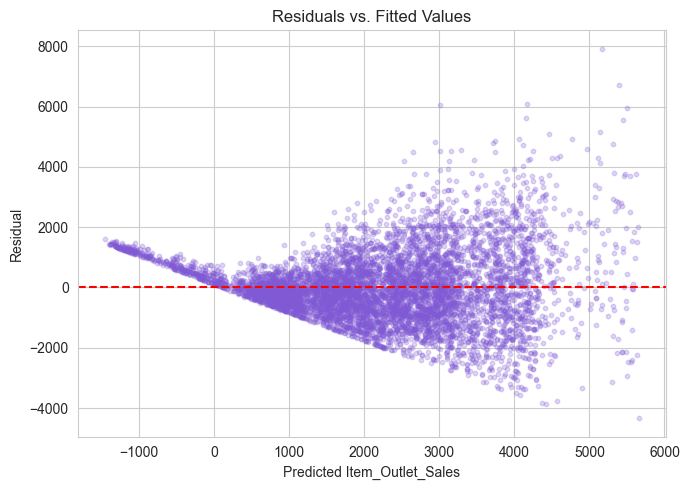

In [25]:
plt.figure(figsize=(7, 5))
plt.scatter(y_train_pred_lr, lr_train_residuals, alpha=0.25, s=10, color="#805ad5")
plt.axhline(0, color='r', linestyle='--', linewidth=1.5)
plt.xlabel('Predicted Item_Outlet_Sales'); plt.ylabel('Residual')
plt.title('Residuals vs. Fitted Values')
plt.tight_layout()
plt.show()


### 10.4 Residual Normality

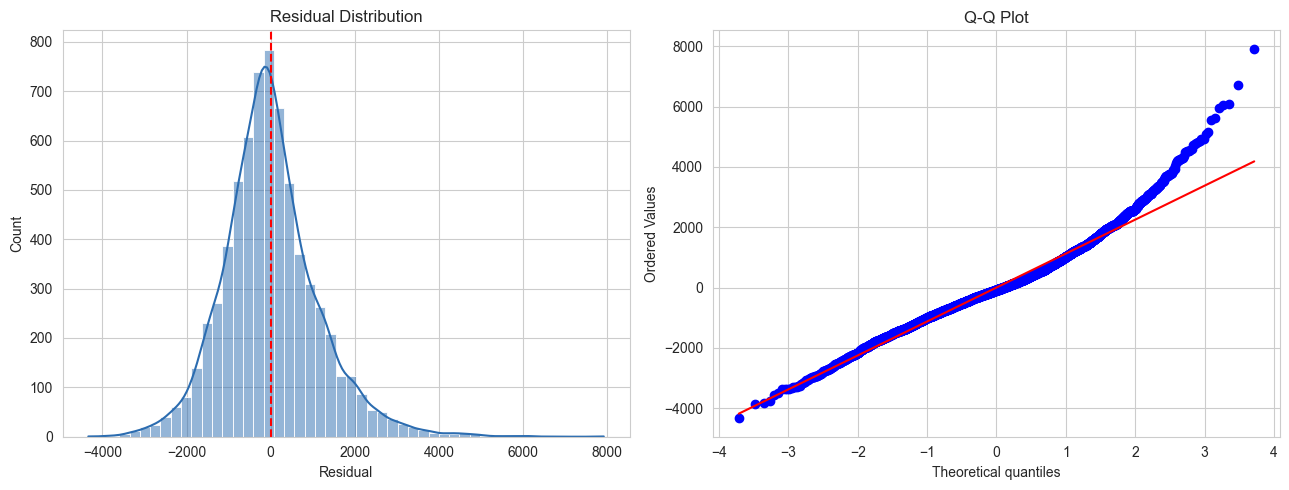

Note: with ~6,800 observations, formal normality tests (e.g. Shapiro-Wilk) will flag statistically significant non-normality for even minor deviations -- the Q-Q plot is the more informative read here.


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(lr_train_residuals, bins=50, kde=True, ax=axes[0], color="#2b6cb0")
axes[0].axvline(0, color='r', linestyle='--', linewidth=1.5)
axes[0].set_title('Residual Distribution')
axes[0].set_xlabel('Residual')

stats.probplot(lr_train_residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()
print("Note: with ~6,800 observations, formal normality tests (e.g. Shapiro-Wilk) "
      "will flag statistically significant non-normality for even minor deviations -- "
      "the Q-Q plot is the more informative read here.")


**10.5 Multicollinearity — VIF**

A separate design matrix is created for VIF, using drop_first=True for categorical variables to avoid the dummy-variable trap. An initial VIF check showed infinite VIFs, indicating exact linear dependencies in the design matrix that need to be investigated.

**Hypothesis 1: Outlet_Identifier Determines Outlet_Type and Outlet_Location_Type**`

Each outlet has a fixed store format and location tier, so Outlet_Identifier uniquely determines both Outlet_Type and Outlet_Location_Type.

In [27]:
nunique_per_outlet = X_train.groupby('Outlet_Identifier')[['Outlet_Type', 'Outlet_Location_Type']].nunique()
print("Distinct Outlet_Type / Outlet_Location_Type values per Outlet_Identifier (1 = fully determined):")
print(nunique_per_outlet)


Distinct Outlet_Type / Outlet_Location_Type values per Outlet_Identifier (1 = fully determined):
                   Outlet_Type  Outlet_Location_Type
Outlet_Identifier                                   
OUT010                       1                     1
OUT013                       1                     1
OUT017                       1                     1
OUT018                       1                     1
OUT019                       1                     1
OUT027                       1                     1
OUT035                       1                     1
OUT045                       1                     1
OUT046                       1                     1
OUT049                       1                     1


**Hypothesis 2: Item_Category vs. Item_Type**

Does the engineered Item_Category map almost completely to Item_Type? If each Item_Type corresponds to only one Item_Category, both features contain largely redundant information.

In [28]:
nunique_per_item_type = X_train.groupby('Item_Type')['Item_Category'].nunique()
print("Distinct Item_Category values per Item_Type (1 = fully determined):")
print(nunique_per_item_type)
print(f"\n{(nunique_per_item_type == 1).sum()} of {len(nunique_per_item_type)} Item_Type "
      f"categories map to a single Item_Category.")


Distinct Item_Category values per Item_Type (1 = fully determined):
Item_Type
Baking Goods             1
Breads                   1
Breakfast                1
Canned                   1
Dairy                    2
Frozen Foods             1
Fruits and Vegetables    1
Hard Drinks              1
Health and Hygiene       1
Household                1
Meat                     1
Others                   1
Seafood                  1
Snack Foods              1
Soft Drinks              1
Starchy Foods            1
Name: Item_Category, dtype: int64

15 of 16 Item_Type categories map to a single Item_Category.


**Hypotheses Confirmed**

Both hypotheses are confirmed. Outlet_Identifier is redundant with Outlet_Type and Outlet_Location_Type, while Item_Category is largely redundant with Item_Type. Therefore, both are excluded from the VIF analysis to avoid singularity, but retained in the actual modeling pipeline.

In [29]:
vif_categorical_features = ['Item_Fat_Content', 'Item_Type',
                            'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']

vif_numeric = X_train[numeric_features].fillna(X_train[numeric_features].median())
vif_categorical = X_train[vif_categorical_features].fillna(X_train[vif_categorical_features].mode().iloc[0])
vif_categorical_dummies = pd.get_dummies(vif_categorical, drop_first=True)

vif_design = pd.concat([vif_numeric.reset_index(drop=True),
                         vif_categorical_dummies.reset_index(drop=True)], axis=1)
vif_design = sm.add_constant(vif_design).astype(float)

vif_df = pd.DataFrame({
    'feature': vif_design.columns,
    'VIF': [variance_inflation_factor(vif_design.values, i) for i in range(vif_design.shape[1])]
})
vif_df = vif_df[vif_df['feature'] != 'const'].sort_values('VIF', ascending=False).reset_index(drop=True)
vif_df.head(15)


,feature,VIF
0,Outlet_Size_Medium,102.534008
1,Outlet_Size_Small,82.646909
2,Outlet_Age,49.337081
3,Outlet_Location_Type_Tier 3,33.023153
4,Outlet_Type_Supermarket Type1,29.956104
5,Outlet_Type_Supermarket Type3,14.234826
6,Outlet_Type_Supermarket Type2,10.781107
7,Outlet_Location_Type_Tier 2,7.630853
8,Item_Type_Fruits and Vegetables,2.546012
9,Item_Type_Snack Foods,2.508905


**Reading the VIF Results**

After removing the redundant columns, all VIF values are finite. Outlet-level features still show high multicollinearity, while Item_Type dummies remain low (about 1–2.5). This means outlet-level coefficients should not be over-interpreted. Combined with the earlier linearity and homoscedasticity issues, this supports using tree-based models for better prediction.

## 11. Evaluate Linear Regression (Baseline)

The Linear Regression baseline is evaluated using 5-fold cross-validation RMSE on the training set, ensuring a fair comparison with the non-linear models.

In [30]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_cv_scores = -cross_val_score(lr_baseline_pipe, X_train, y_train, cv=kf,
                                 scoring='neg_root_mean_squared_error', n_jobs=-1)
print(f"Linear Regression   CV RMSE: {lr_cv_scores.mean():>10,.1f}  (+/- {lr_cv_scores.std():,.1f})")


Linear Regression   CV RMSE:    1,148.2  (+/- 29.5)


**12. Non-Linear Models**

Three ensemble regressors from bagging and boosting families are compared with the Linear Regression baseline. These tree-based models are less dependent on linearity, homoscedasticity, residual normality, and low multicollinearity, making them suitable alternatives based on the findings from Section 10.

In [31]:
models = {
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
    'XGBoost': XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, objective='reg:squarederror'),
}
print("Non-linear model candidates defined:", list(models.keys()))


Non-linear model candidates defined: ['Random Forest', 'Gradient Boosting', 'XGBoost']


## 13. 5-Fold Cross-Validation

Each non-linear candidate is wrapped in the same preprocessing pipeline
and scored with 5-fold CV on negative RMSE, using only the training set —
exactly like the Linear Regression baseline in Section 11, so the results
are directly comparable.

In [32]:
cv_results = {'Linear Regression': lr_cv_scores}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=kf,
                              scoring='neg_root_mean_squared_error', n_jobs=-1)
    cv_results[name] = -scores
    print(f"{name:24s} CV RMSE: {-scores.mean():>10,.1f}  (+/- {scores.std():,.1f})")


Random Forest            CV RMSE:    1,157.9  (+/- 23.8)


Gradient Boosting        CV RMSE:    1,096.1  (+/- 23.8)


XGBoost                  CV RMSE:    1,199.3  (+/- 29.9)


## 14. Compare Models — CV RMSE

All four models (the Linear Regression baseline plus the three non-linear
candidates) are compared together on the same footing.

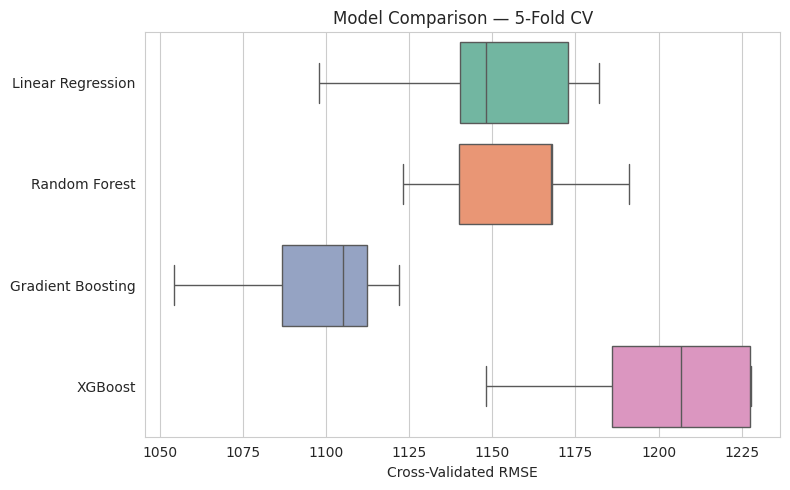

In [33]:
cv_df = pd.DataFrame(cv_results)
plt.figure(figsize=(8, 5))
sns.boxplot(data=cv_df, orient='h', palette='Set2')
plt.xlabel('Cross-Validated RMSE')
plt.title('Model Comparison — 5-Fold CV')
plt.tight_layout()
plt.show()


**Model comparison table:**

In [34]:
cv_summary = pd.DataFrame({
    'Mean CV RMSE': cv_df.mean(),
    'Std CV RMSE': cv_df.std(ddof=0),  # population std (ddof=0), matching the printed +/- values above
}).sort_values('Mean CV RMSE')
cv_summary.round(1)


,Mean CV RMSE,Std CV RMSE
Gradient Boosting,1096.1,23.8
Linear Regression,1148.2,29.5
Random Forest,1157.9,23.8
XGBoost,1199.3,29.9


## 15. Select Best Model

The model with the lowest mean CV RMSE is selected — purely on this
evidence, not on which algorithm sounds more sophisticated.

In [35]:
best_model_name = cv_df.mean().idxmin()
print(f"Best model by mean CV RMSE: {best_model_name} ({cv_df.mean().min():,.1f})")


Best model by mean CV RMSE: Gradient Boosting (1,096.1)


## 16. Hyperparameter Tuning

The selected model is tuned with `RandomizedSearchCV`, still scored on CV
RMSE using only the training set — the model was already selected in
Section 15, based purely on the untuned comparison, so the test set plays
no role in either decision.

In [36]:
param_distributions = {
    'Random Forest': {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [None, 6, 10, 14],
        'model__min_samples_leaf': [1, 3, 5],
    },
    'Gradient Boosting': {
        'model__n_estimators': [100, 200, 300],
        'model__learning_rate': [0.03, 0.05, 0.1, 0.2],
        'model__max_depth': [2, 3, 4, 6],
        'model__min_samples_leaf': [1, 3, 5],
        'model__subsample': [0.7, 0.85, 1.0],
    },
    'XGBoost': {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [3, 4, 6, 8],
        'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
        'model__subsample': [0.7, 0.85, 1.0],
        'model__colsample_bytree': [0.7, 0.85, 1.0],
    },
}

if best_model_name == 'Linear Regression':
    # Already fit in Section 9; plain OLS has no meaningful hyperparameters to search.
    best_model = lr_baseline_pipe
    tuned_cv_rmse = cv_df.mean().min()  # no tuning happened, so this stays the same as the untuned CV score
    print("Linear Regression selected -- no hyperparameters to tune; reusing the Section 9 baseline fit.")
else:
    base_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', models[best_model_name])])
    search = RandomizedSearchCV(
        base_pipe, param_distributions[best_model_name], n_iter=20, cv=kf,
        scoring='neg_root_mean_squared_error', n_jobs=-1, random_state=RANDOM_STATE, verbose=0
    )
    search.fit(X_train, y_train)
    print(f"Best parameters: {search.best_params_}")
    print(f"Best CV RMSE: {-search.best_score_:,.1f}")
    best_model = search.best_estimator_
    tuned_cv_rmse = -search.best_score_


Best parameters: {'model__subsample': 0.7, 'model__n_estimators': 200, 'model__min_samples_leaf': 1, 'model__max_depth': 3, 'model__learning_rate': 0.03}
Best CV RMSE: 1,094.2


## 17. Final Model Locked

`RandomizedSearchCV` (or the Section 9 fit, for Linear Regression) already
refits the winning configuration on the **entire training set** by
default — so `best_model` at this point is the final, locked model. No
further changes will be made to it based on anything seen after this
cell, including the test set.

In [37]:
print(f"Final locked model: {best_model_name}")
print(best_model.named_steps['model'])


Final locked model: Gradient Boosting
GradientBoostingRegressor(learning_rate=0.03, n_estimators=200, random_state=42,
                          subsample=0.7)


## 18. Held-Out Test Set Evaluation

The test set is used **only after the final model has been selected,
tuned, and locked**. It provides an unbiased estimate of how the final
pipeline performs on unseen data. The subsequent residual analysis and
permutation importance are strictly post-hoc analyses and do not feed
back into model selection or tuning.

In [38]:
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Final model: {best_model_name}")
print(f"Test RMSE : {rmse:,.1f}")
print(f"Test MAE  : {mae:,.1f}")
print(f"Test R^2  : {r2:.4f}")


Final model: Gradient Boosting
Test RMSE : 1,027.9
Test MAE  : 719.4
Test R^2  : 0.6113


**Stage-by-stage progression:**

In [39]:
progression = pd.DataFrame({
    'Stage': ['Best untuned model (CV)', 'Tuned model (CV)', 'Final test evaluation (one-time)'],
    'Model': [best_model_name, best_model_name, best_model_name],
    'RMSE': [cv_df.mean().min(), tuned_cv_rmse, rmse],
})
progression.round(1)


,Stage,Model,RMSE
0,Best untuned model (CV),Gradient Boosting,1096.1
1,Tuned model (CV),Gradient Boosting,1094.2
2,Final test evaluation (one-time),Gradient Boosting,1027.9


**Actual vs. predicted.** Points should cluster along the diagonal for a well-fit model.

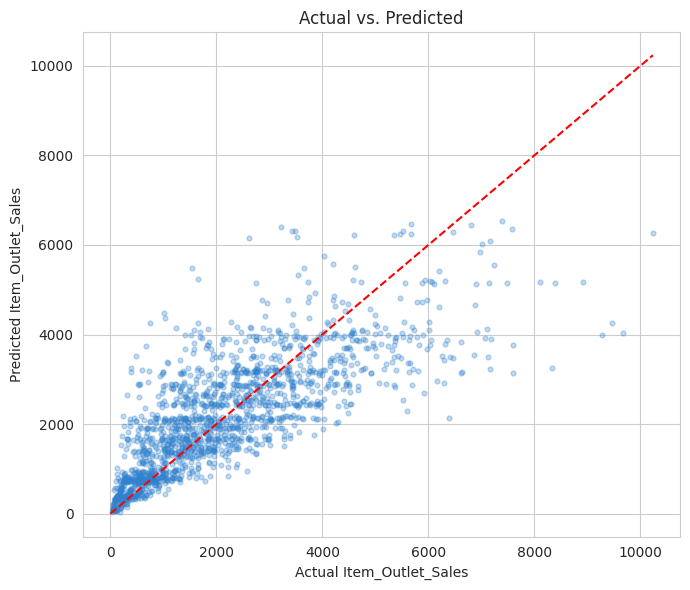

In [40]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=12, color="#3182ce")
lims = [0, max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', linewidth=1.5)
plt.xlabel('Actual Item_Outlet_Sales'); plt.ylabel('Predicted Item_Outlet_Sales')
plt.title('Actual vs. Predicted')
plt.tight_layout()
plt.show()


## 19. Residual Analysis

Residuals should scatter randomly around zero with no obvious pattern or
funnel shape. A funnel (residual spread growing with predicted value) is
common in sales-type targets and, if present, suggests the model is less
precise for high-sales items specifically.

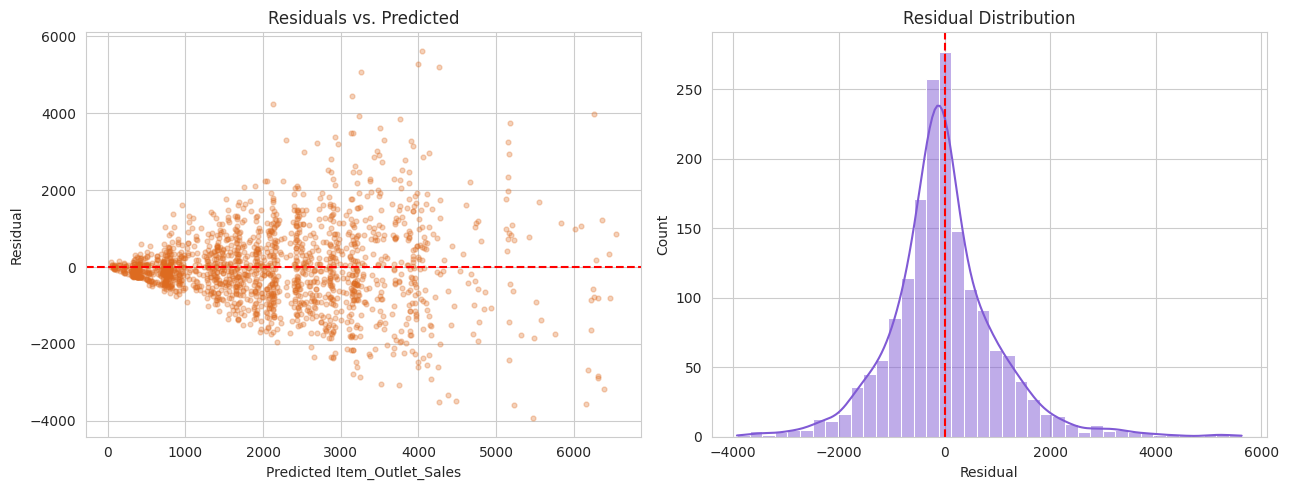

Mean residual: -21.20 (should be close to 0)
Residual std:  1,027.96


In [41]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_pred, residuals, alpha=0.3, s=12, color="#dd6b20")
axes[0].axhline(0, color='r', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted Item_Outlet_Sales'); axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs. Predicted')

sns.histplot(residuals, bins=40, kde=True, ax=axes[1], color="#805ad5")
axes[1].axvline(0, color='r', linestyle='--', linewidth=1.5)
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')
plt.tight_layout()
plt.show()

print(f"Mean residual: {residuals.mean():,.2f} (should be close to 0)")
print(f"Residual std:  {residuals.std():,.2f}")


**Reading the results.** The mean residual is close to zero, so
predictions aren't systematically biased high or low overall. There is a
visible **funnel shape**, though: the spread of residuals grows
noticeably wider for higher predicted sales, meaning the model is
consistently more precise for low-and-mid-sales items than for the
highest-selling ones. This is a common pattern for sales-type targets —
the largest sales figures are driven by the rarest, most extreme
combinations of price and outlet, which the model has the least data to
learn from. The residual distribution itself is heavier-tailed than a
clean normal (visible in the sharp central peak with longer tails on both
sides), which is worth knowing for anyone using this model's predictions
directly: a larger absolute error is more likely at the high end of the sales range
than the RMSE alone might suggest.

## 20. Feature Importance

This is **post-hoc permutation importance on the held-out test set** —
useful for interpretation, but not part of model selection or tuning, and
its results are not used to change the model in any way. Permutation
importance is model-agnostic, so it works the same way regardless of
which model was selected, unlike `.feature_importances_`, which not every
model type exposes.

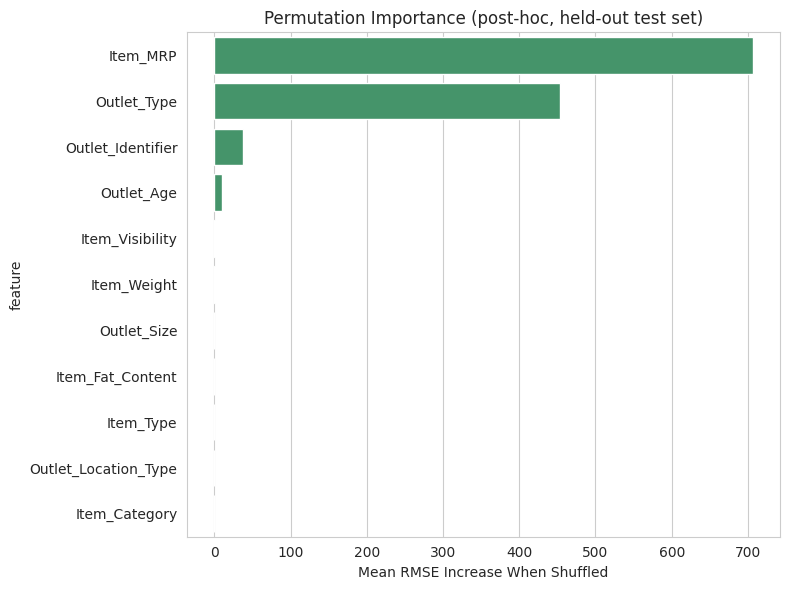

In [42]:
perm_result = permutation_importance(
    best_model, X_test, y_test, n_repeats=10,
    random_state=RANDOM_STATE, scoring='neg_root_mean_squared_error', n_jobs=-1
)
imp_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std,
}).sort_values('importance_mean', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=imp_df, x='importance_mean', y='feature', color="#38a169")
plt.xlabel('Mean RMSE Increase When Shuffled')
plt.title('Permutation Importance (post-hoc, held-out test set)')
plt.tight_layout()
plt.show()


## 21. Save Model and Inference

The full pipeline — grouped-mode imputation, preprocessing, and the
tuned model — is serialized as a single object with `joblib`. To be
precise about what this pipeline expects: it is **not** a raw,
straight-from-`Train.csv` row. It expects the same *engineered* input
format used during training — `Item_Category` and `Outlet_Age` already
computed exactly as in Section 5, with `Item_Identifier` and
`Outlet_Establishment_Year` already dropped. Given input in that format,
the saved pipeline handles imputation, encoding, scaling, and prediction
automatically.

In [43]:
joblib.dump(best_model, 'bigmart_sales_pipeline.pkl')
print("Saved to bigmart_sales_pipeline.pkl")


Saved to bigmart_sales_pipeline.pkl


In [44]:
loaded_model = joblib.load('bigmart_sales_pipeline.pkl')

held_out_row = X_test.iloc[[0]]  # a held-out test-set row, used here only to demonstrate the inference call
prediction = loaded_model.predict(held_out_row)[0]

print(f"Predicted Item_Outlet_Sales: {prediction:,.2f}")
print(f"Actual Item_Outlet_Sales:    {y_test.iloc[0]:,.2f}")


Predicted Item_Outlet_Sales: 1,289.82
Actual Item_Outlet_Sales:    1,743.06
